# Latent-space probe results — exploratory plots

Loads every `predictions.csv` under `output/latent_probes/` and the aggregated `summary.csv`.
Headline plot: violin of per-row residuals (predicted − true, transformed space) per probe, split by baseline.

Baselines:
- **none** — real latents.
- **gaussian** — iid N(0,1) features of identical shape (capacity-of-MLP floor).
- **shuffle** — real latents, rows permuted (signal floor; preserves latent distribution / inter-dim correlations).


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

ROOT = Path('.').resolve()
PROBES   = ['flux_skew', 'flux_kurt', 'lit_prot', 'tars_prot', 'num_flares', 'total_ed']
BASELINES = ['none', 'gaussian', 'shuffle']
BASELINE_COLOR = {'none': '#2c7fb8', 'gaussian': '#c0c0c0', 'shuffle': '#8a8a8a'}

def run_dir(probe, baseline):
    return ROOT / (probe if baseline == 'none' else f'{probe}__{baseline}')

summary = pd.read_csv(ROOT / 'summary.csv')
summary

,probe,baseline,transform,n,r,mae,rmse,r_raw,mae_raw,run_dir
0,flux_kurt,gaussian,asinh,31912,-0.008954,1.227289,1.753572,-0.000261,2.809850e+01,flux_kurt__gaussian
1,flux_kurt,none,asinh,31912,0.998682,0.056948,0.090117,0.854897,4.762332e+00,flux_kurt
2,flux_kurt,shuffle,asinh,31912,0.020390,1.219581,1.751825,0.009423,2.808900e+01,flux_kurt__shuffle
3,flux_skew,gaussian,asinh,31912,-0.004250,0.421113,0.739760,-0.003908,9.393607e-01,flux_skew__gaussian
4,flux_skew,none,asinh,31912,0.983369,0.034873,0.134787,0.130183,1.908977e+06,flux_skew
5,flux_skew,shuffle,asinh,31912,0.007044,0.412366,0.739468,0.005841,9.303016e-01,flux_skew__shuffle
6,lit_prot,gaussian,log10,9431,0.008722,0.497981,0.587686,-0.004254,4.304191e+00,lit_prot__gaussian
7,lit_prot,none,log10,9431,0.868018,0.179581,0.291958,0.669917,2.119835e+00,lit_prot
8,lit_prot,shuffle,log10,9431,0.008793,0.498351,0.587771,0.006666,4.305672e+00,lit_prot__shuffle
9,num_flares,gaussian,log10,13257,-0.016292,0.542714,0.657017,-0.045207,2.151937e+01,num_flares__gaussian


In [2]:
rows = []
for probe in PROBES:
    for baseline in BASELINES:
        p = run_dir(probe, baseline) / 'predictions.csv'
        if not p.exists():
            print(f'missing: {p}')
            continue
        df = pd.read_csv(p)
        df['probe'] = probe
        df['baseline'] = baseline
        df['residual'] = df['y_pred_transformed'] - df['y_true_transformed']
        df['abs_residual'] = df['residual'].abs()
        rows.append(df)
preds = pd.concat(rows, ignore_index=True)
print(f'{len(preds):,} rows across {preds["probe"].nunique()} probes x {preds["baseline"].nunique()} baselines')
preds.head()

362,595 rows across 6 probes x 3 baselines


,GaiaDR3_ID,sector,fold,y_true_raw,y_pred_raw,y_true_transformed,y_pred_transformed,probe,baseline,residual,abs_residual
0,4931155036049677312,2,0,7.982227,8.307035,2.774265,2.813853,flux_skew,none,0.039588,0.039588
1,4931155036049677312,3,0,7.516752,7.841545,2.714677,2.756624,flux_skew,none,0.041947,0.041947
2,4931155036049677312,29,0,1.450021,1.473740,1.166716,1.180108,flux_skew,none,0.013392,0.013392
3,4931155036049677312,30,0,0.627900,0.646828,0.592601,0.608562,flux_skew,none,0.015961,0.015961
4,5769888374304313472,65,4,-0.244057,-0.228689,-0.241697,-0.226742,flux_skew,none,0.014956,0.014956


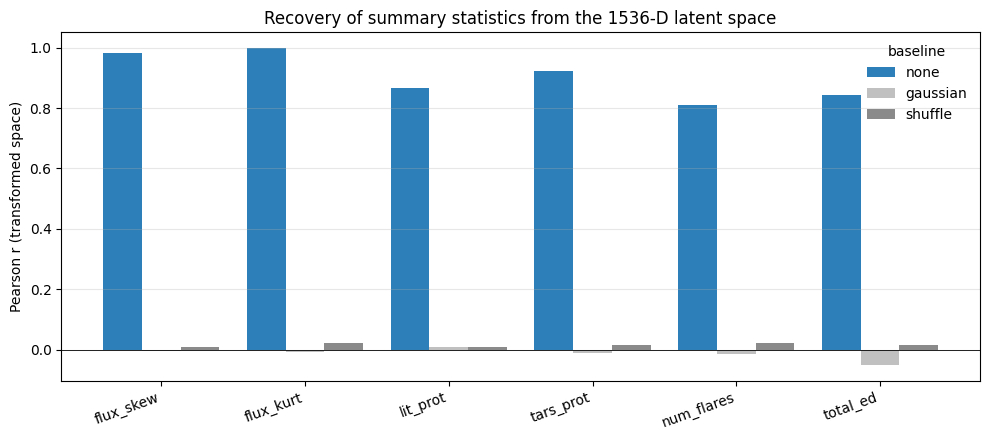

In [3]:
# Pearson r per probe x baseline (sanity check vs summary.md).
fig, ax = plt.subplots(figsize=(10, 4.5))
width = 0.27
x = np.arange(len(PROBES))
for i, b in enumerate(BASELINES):
    rs = [float(summary[(summary.probe == p) & (summary.baseline == b)]['r'].iloc[0])
          if not summary[(summary.probe == p) & (summary.baseline == b)].empty else np.nan
          for p in PROBES]
    ax.bar(x + (i - 1) * width, rs, width, label=b, color=BASELINE_COLOR[b])
ax.axhline(0, color='k', lw=0.6)
ax.set_xticks(x); ax.set_xticklabels(PROBES, rotation=20, ha='right')
ax.set_ylabel('Pearson r (transformed space)')
ax.set_title('Recovery of summary statistics from the 1536-D latent space')
ax.legend(title='baseline', frameon=False)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()

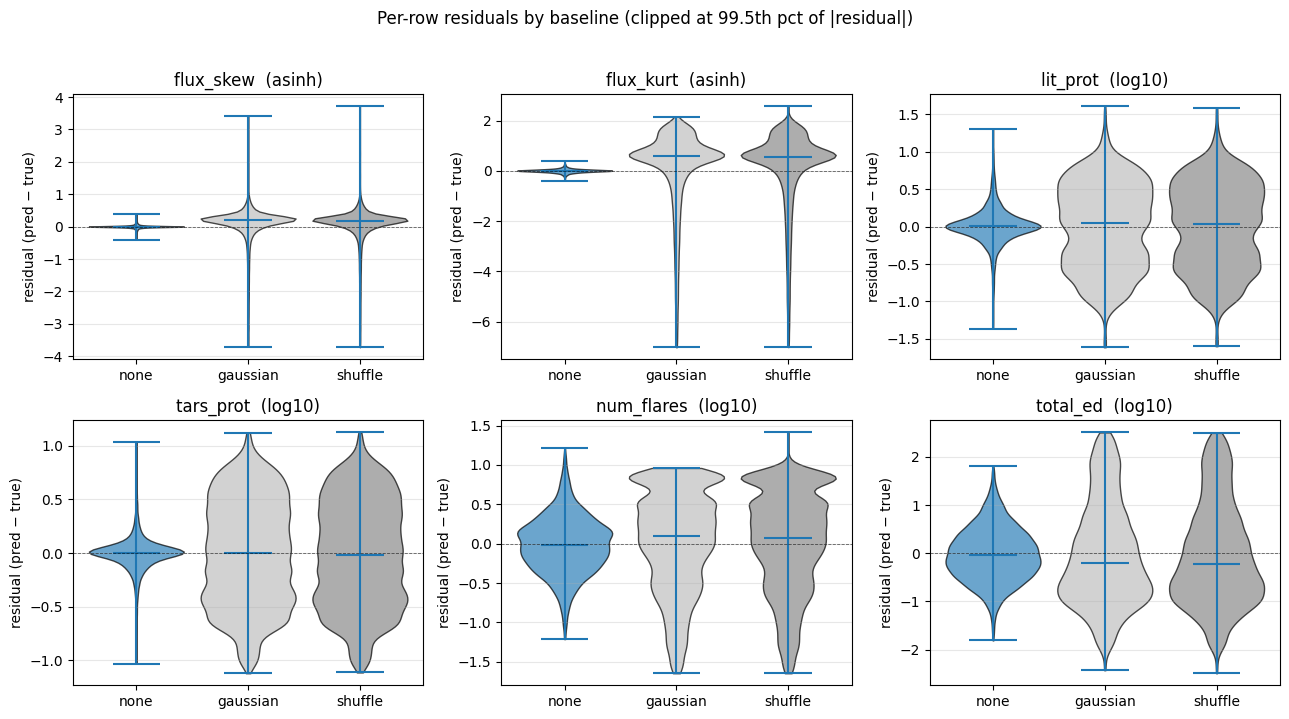

In [4]:
# Violin: residual distribution per probe, split by baseline.
# Residual lives in the transformed space the model trained in (asinh / log10),
# so units differ across probes -> one subplot per probe.

CLIP_PCTL = 99.5  # trim extreme outliers for readability; set to 100 for full tails

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=False)
for ax, probe in zip(axes.ravel(), PROBES):
    data, labels, colors = [], [], []
    for b in BASELINES:
        r = preds[(preds.probe == probe) & (preds.baseline == b)]['residual'].to_numpy()
        if CLIP_PCTL < 100:
            lim = np.nanpercentile(np.abs(r), CLIP_PCTL)
            r = r[np.abs(r) <= lim]
        data.append(r); labels.append(b); colors.append(BASELINE_COLOR[b])
    parts = ax.violinplot(data, showmeans=False, showmedians=True, widths=0.85)
    for body, c in zip(parts['bodies'], colors):
        body.set_facecolor(c); body.set_edgecolor('k'); body.set_alpha(0.7)
    ax.axhline(0, color='k', lw=0.6, ls='--', alpha=0.6)
    ax.set_xticks(np.arange(1, len(BASELINES) + 1)); ax.set_xticklabels(labels)
    transform = summary[summary.probe == probe]['transform'].iloc[0]
    ax.set_title(f'{probe}  ({transform})')
    ax.set_ylabel('residual (pred − true)')
    ax.grid(axis='y', alpha=0.3)
fig.suptitle(f'Per-row residuals by baseline (clipped at {CLIP_PCTL}th pct of |residual|)', y=1.02)
fig.tight_layout()

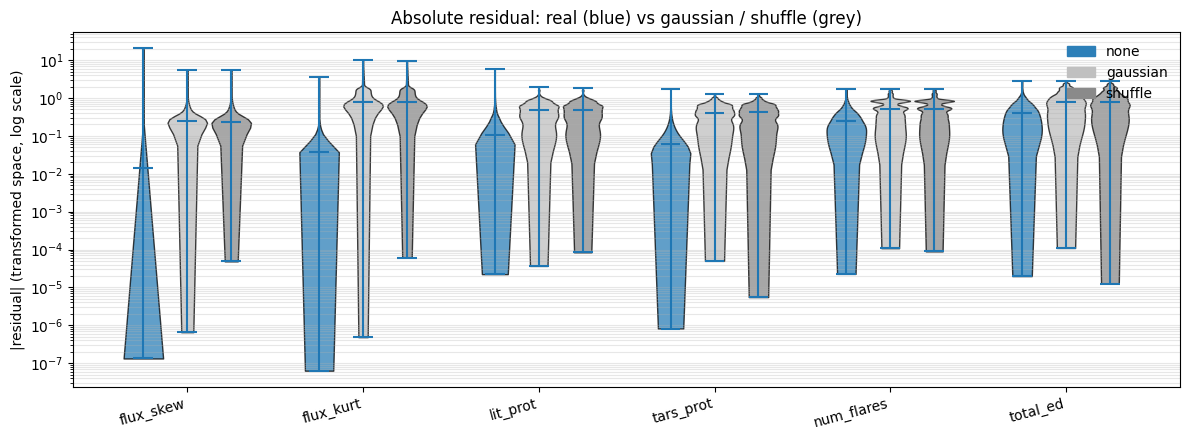

In [5]:
# Alt view: |residual| on a log y-axis -> all six probes on one panel.
# Useful for eyeballing the real-vs-baseline gap at a glance.
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(12, 4.5))
positions, tick_pos, tick_labels = [], [], []
for i, probe in enumerate(PROBES):
    for j, b in enumerate(BASELINES):
        positions.append(i * 4 + j)
    tick_pos.append(i * 4 + 1); tick_labels.append(probe)

data, colors = [], []
for probe in PROBES:
    for b in BASELINES:
        r = preds[(preds.probe == probe) & (preds.baseline == b)]['abs_residual'].to_numpy()
        r = r[r > 0]
        data.append(r); colors.append(BASELINE_COLOR[b])

parts = ax.violinplot(data, positions=positions, widths=0.9, showmedians=True)
for body, c in zip(parts['bodies'], colors):
    body.set_facecolor(c); body.set_edgecolor('k'); body.set_alpha(0.75)
ax.set_yscale('log')
ax.set_xticks(tick_pos); ax.set_xticklabels(tick_labels, rotation=15, ha='right')
ax.set_ylabel('|residual| (transformed space, log scale)')
ax.set_title('Absolute residual: real (blue) vs gaussian / shuffle (grey)')
ax.grid(axis='y', alpha=0.3, which='both')
ax.legend(handles=[Patch(color=BASELINE_COLOR[b], label=b) for b in BASELINES],
          frameon=False, loc='upper right')
fig.tight_layout()

In [ ]:
# Single-panel violin of signed residuals (linear space), real vs gaussian only.
# Same layout as the log-scale plot; matches the per-probe violin values.
# Residual units differ across probes (asinh for moments, log10 for Prot/flares),
# so a shared linear axis squashes the smaller-scale probes; CLIP_PCTL trims the
# heaviest tails to keep the plot readable.
from matplotlib.patches import Patch

BASELINES_2 = ['none', 'gaussian']
CLIP_PCTL = 99.0  # of |residual|; raise to 100 for full tails

fig, ax = plt.subplots(figsize=(12, 4.5))
positions, tick_pos, tick_labels = [], [], []
group_w = len(BASELINES_2) + 1  # gap between probe groups
for i, probe in enumerate(PROBES):
    for j, _ in enumerate(BASELINES_2):
        positions.append(i * group_w + j)
    tick_pos.append(i * group_w + (len(BASELINES_2) - 1) / 2)
    tick_labels.append(probe)

data, colors = [], []
for probe in PROBES:
    for b in BASELINES_2:
        r = preds[(preds.probe == probe) & (preds.baseline == b)]['residual'].to_numpy()
        if CLIP_PCTL < 100:
            lim = np.nanpercentile(np.abs(r), CLIP_PCTL)
            r = r[np.abs(r) <= lim]
        data.append(r); colors.append(BASELINE_COLOR[b])

parts = ax.violinplot(data, positions=positions, widths=0.85, showmedians=True)
for body, c in zip(parts['bodies'], colors):
    body.set_facecolor(c); body.set_edgecolor('k'); body.set_alpha(0.75)
ax.axhline(0, color='k', lw=0.6, ls='--', alpha=0.6)
ax.set_xticks(tick_pos); ax.set_xticklabels(tick_labels, rotation=15, ha='right')
ax.set_ylabel('residual (pred − true), transformed space')
ax.set_title(f'Per-row signed residuals: real (blue) vs gaussian (grey)  — clipped at {CLIP_PCTL}th pct of |residual|')
ax.grid(axis='y', alpha=0.3)
ax.legend(handles=[Patch(color=BASELINE_COLOR[b], label=b) for b in BASELINES_2],
          frameon=False, loc='upper left')
fig.tight_layout()

In [6]:
# Scratch cell - explore from here.
# preds columns: GaiaDR3_ID, sector, fold, y_true_raw, y_pred_raw,
#                y_true_transformed, y_pred_transformed, probe, baseline, residual, abs_residual

preds.groupby(['probe', 'baseline'])['abs_residual'].describe(percentiles=[0.5, 0.95])[['count', 'mean', '50%', '95%']]

count      mean       50%       95%
probe      baseline                                       
flux_kurt  gaussian  31912.0  1.227289  0.792574  4.101037
           none      31912.0  0.056948  0.037914  0.174617
           shuffle   31912.0  1.219581  0.779025  4.098563
flux_skew  gaussian  31912.0  0.421113  0.245608  1.754101
           none      31912.0  0.034873  0.014607  0.140235
           shuffle   31912.0  0.412366  0.231233  1.769304
lit_prot   gaussian   9431.0  0.497981  0.478320  1.005145
           none       9431.0  0.179581  0.103711  0.614016
           shuffle    9431.0  0.498351  0.480813  1.003309
num_flares gaussian  13257.0  0.542714  0.516910  1.262793
           none      13257.0  0.298347  0.241938  0.779694
           shuffle   13257.0  0.541583  0.521111  1.267595
tars_prot  gaussian  21096.0  0.428270  0.414283  0.887743
           none      21096.0  0.112739  0.061957  0.392338
           shuffle   21096.0  0.427824  0.415741  0.881719
total_ed   gaussian  13257.0  0.896985  0.794968  2.078684
           none      13257.0  0.460784  0.389991  1.122890
           shuffle   13257.0  0.894577  0.791398  2.068888